In [68]:
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime
from pathlib import Path
import ast
import matplotlib
import matplotlib as mpl
import matplotlib.dates as mdates
from datetime import timedelta
import random 
import json
import pandas as pd
from ast import literal_eval
random.seed(3)
myFmt = mdates.DateFormatter('%H:%M:%S') 


#RMSE/MAE analysis
# def time_reader(fname, core=4):
#     lines=open(fname).readlines()
#     start_iter=0
#     end_iter = 0
#     counter=0
#     str_dt = lines[0].strip().split(" Sync ")[0].split(".")[0].split(" ")[-1]
#     start_iter = datetime.strptime(str_dt, "%H:%M:%S")
#     core_times = [float(i.strip().split(" ")[1]) for i in lines[1*core:1*core+core]]
#     str_dt = lines[1*core+core].strip().split(" Sync ")[0].split(".")[0].split(" ")[-1]
#     end_iter = datetime.strptime(str_dt, "%H:%M:%S")
#     return (core_times, start_iter, end_iter)

def time_reader(fname, core=4):
    lines=open(fname).readlines()
    start_iter=0
    end_iter = 0
    counter=0
    str_dt = lines[0].strip().split(" Sync ")[0].split(".")[0].split(" ")[-1]
    start_iter = datetime.strptime(str_dt, "%H:%M:%S")
    # core_times = [float(i.strip().split(" ")[1]) for i in lines[1*core:1*core+core]]
    core_times=[]
    all_times = []
    for i in lines[1*core:1*core+core]:
        num_list = ' '.join(i.strip().split(" ")[2:])
        # print(i)
        # print(num_list)
        num_list = ast.literal_eval(num_list)
        core_times.append(sum(num_list))
        all_times.extend(num_list)
    #core_times = [ sum(ast.literal_eval(i.strip().split(" ")[-1])) for i in lines[1*core:1*core+core]]

    str_dt = lines[1*core+core].strip().split(" Sync ")[0].split(".")[0].split(" ")[-1]
    end_iter = datetime.strptime(str_dt, "%H:%M:%S")
    return (core_times, start_iter, end_iter, all_times)


def cdf_gen(arr, e=False):
    sorted_arr = sorted(arr)
    y=[]
    for x in range(len(sorted_arr)):
        counter = len(sorted_arr[x+1:]) if e else x+1
        y.append(counter/len(sorted_arr))
    return sorted_arr, y 

def time_predictor(peak_times, fp, bg_load=0, t=38):
    # sorted(fp)

    maybe_gnt = [0]*len(peak_times)
    achieved_fps = [i for i in peak_times]
    if len(peak_times)==1 and bg_load==0:
        return achieved_fps
    elif len(peak_times)==1:
        val = tf_calc(len(peak_times)+bg_load, t)
        # print(val, bg_load)
        # val = val if val < 0.5 else 0.5
        val = val if val < 0.9 else 0.9
        # gnt = (peak_times[0]-maybe_gnt[0])/(1-val)
        gnt = 2*(peak_times[0])/(2-val)
        achieved_fps = [gnt]
        return achieved_fps

def tf_calc(w, n):
    y=0
    if w < 8:
        y = 0.157 - 0.004*n + 0.075*w
    else:
        y = 0.667 - 0.008*n + 0.023*w
    return y


def simulation_reader(fname, skip_ts=False, agg_flag="mean"):
    #assumed to be in order of arrival already
    df = pd.read_csv(fname)
    time_stamp_map={}
    if skip_ts:
        for d in df.iterrows():
            d=d[1]
            ts = d["clock"]
            if ts not in time_stamp_map:
                time_stamp_map[ts] = []
            vals = df[(df["clock"]==ts)]
            j = [ i for i in vals['task_id'].unique()]
            for t in j:
                w_t = vals[vals["task_id"]==t]["task_wait"].values[0]
                r_t = vals[vals["task_id"]==t]["run_time"].values[0]
                arr_t = vals[vals["task_id"]==t]["task_arrival"].values[0]
                world = vals[vals["task_id"]==t]["world"].values[0]
                bn = vals[vals["task_id"]==t]["bn"].values[0]
                bs = vals[vals["task_id"]==t]["bs"].values[0]
                if [t, w_t, r_t, arr_t, world, bn, bs ] not in time_stamp_map[ts]:
                    time_stamp_map[ts].append([t, w_t, r_t, arr_t, world, bn, bs ])
        
    time_taken={}
    overhead={}
    bn={}
    bs={}
    world={}
    added_time={}
    ty={}
    devs_used={}
    bw={}
    for t_id in df['task_id']:
        j = t_id.split(".")[0]
        if j not in time_taken:
            time_taken[j]=0
            overhead[j]=0
            bn[j]=0
            bs[j]=0
            bw[j]=0
            world[j]=0
            added_time[j]=0
            ty[j]='c'
        else:
            continue
        # print(df[df['task_id']==t_id]['clock'][-1:])
        # print(df[df['task_id']==t_id]['clock'].values[-1] )
        cor=1
        arr_t = min(df[df['task_id']==t_id]['task_arrival'].values)
        wait_t = max(df[df['task_id']==t_id]['task_wait'].values)
        rem_t = df[df['task_id']==t_id]['task_remaining_time'].values[0]
        # run_t = max(df[df['task_id']==t_id]['run_time'].values)*12
        run_t = max(df[df['task_id']==t_id]['run_time'].values)
        d_bn = df[df['task_id']==t_id]['bn'].values[-1] 
        d_bs = df[df['task_id']==t_id]['bs'].values[-1] 
        world[j]=df[df['task_id']==t_id]['world'].values[-1] 
        overhead[j] = len(df[(df['clock']==arr_t) & (df["task_wait"]==0)].values)
        devs_used[j] = df[df['task_id']==t_id]["devs_used"].values[0]
        # bw[j] = np.median(df[df['task_id']==t_id]["bw"].values)
        # bw[j] = np.max(df[df['task_id']==t_id]["bw"].values)
        if agg_flag=="mean":
            bw[j] = np.mean(df[df['task_id']==t_id]["bw"].values)
        elif agg_flag=="median":
            bw[j] = np.median(df[df['task_id']==t_id]["bw"].values)
        elif agg_flag=="min":
            bw[j] = np.min(df[df['task_id']==t_id]["bw"].values)
        elif agg_flag=="max":
            bw[j] = np.max(df[df['task_id']==t_id]["bw"].values)
        elif agg_flag=="exp":
            freq_map={}
            for k in df[df['task_id']==t_id]["bw"].values:
                if k not in freq_map:
                    freq_map[k]=0
                freq_map[k]+=1
            bw[j] = sum([freq_map[k]*k/sum(freq_map.values()) for k in freq_map])
        else:
            bw[j] = (np.max(df[df['task_id']==t_id]["bw"].values)+np.min(df[df['task_id']==t_id]["bw"].values))/2

        time_taken[j] =  (arr_t + run_t*cor + wait_t)#rem_t
        # time_taken[j] =  arr_t + rem_t#rem_t
        # time_taken[j] = df[df['task_id']==t_id]['clock'].values[-1] + df[df['task_id']==t_id]['run_time'].values[-1] 
        time_taken[j] = float(time_taken[j])
        if "comp" not in fname and "comm" not in fname:
            ty[j]=df[df['task_id']==t_id]['type'].values[0]
        # overhead_df = df.
        visited=[]
        for d_ind, d in enumerate(df.iterrows()):
            # if d_ind==0:
            #     continue
            # print(d[1]["clock"])
            # print(d["clock"].values)
            d=d[1]
            if d['task_id'] in visited:
                continue
            visited.append(d['task_id'])
            # try:
            #     overhead[j] = df[df['task_id']==t_id]['util'].values[0]#np.floor(d["util"]*39)
            # except Exception as e:
            #     overhead[j] = (overhead[j]+1) if d['clock']+d['task_wait']<=arr_t+wait_t<= d['clock']+d['task_wait']+d['run_time']*cor else (overhead[j]+0)
        bn[j] = d_bn
        bs[j] = d_bs
        added_time[j]=[arr_t,wait_t]
    return time_taken, overhead, bs, bn, world, added_time, ty, time_stamp_map, devs_used, bw


def best_fit_reader(fname, subcluster, model, world, bg, bs, bn, bw=240, ty='c', col_flag="mean", agg_flag="mean", nw_var=False):
    df = pd.read_csv(fname)
    df = df[ (df["model"]==model) & (df["world"]==world) ]
    df = df[ (df["subcluster"]=="bramble-2-4") | (df["subcluster"]=="bramble-2-6") | (df["subcluster"]=="bramble-2-5")  ]
    # df = df[ df["subcluster"]==subcluster ]
    ranks_to_time_slice = {r:[0]*r+[1]*bn+[0]*(world-r-1) for r in range(world)}
    time_to_ranks_slice = {}
    for s in range(len(ranks_to_time_slice[0])):
        if s not in time_to_ranks_slice:
            time_to_ranks_slice[s]=[]
        for r in ranks_to_time_slice:
            if ranks_to_time_slice[r][s]!=0:
                time_to_ranks_slice[s].append(r)
    # print(time_to_ranks_slice)
    
    mean_rt=0
    pred_rt=0
    naive_pred=0
    std_val=[]
    # std_val=0
    # bw=240 #mbps
    # print(len(time_to_ranks_slice), world, bg, )
    dev_time_map = {r:[] for r in range(world)}
    for s in time_to_ranks_slice:
        slice_arr=[0]
        pred_slice_arr=[0]
        std_arr=[]
        nw_arr=[0]
        # bg= (bg+len(time_to_ranks_slice[s])) if len(time_to_ranks_slice[s])>1 else bg
        bg = bg if bg > 0 else 0
        overhead = len(time_to_ranks_slice[s]) - 1 + bg
        overhead = overhead if overhead > 0 else 0
        og_o = overhead
        # print(og_o, overhead, len(time_to_ranks_slice[s]), bg)
        # print(overhead)
            # overhead = bg+overhead+min([abs(b - bg-overhead) for b in set(vit_df[vit_df["world"]==world]["bg_load"].values)])
            # if overhead not in set(vit_df[vit_df["world"]==world]["bg_load"].values):
            #     overhead = bg+overhead-min([abs(b - bg-overhead) for b in set(vit_df[vit_df["world"]==world]["bg_load"].values)])
            # print(set(vit_df[vit_df["world"]==world]["bg_load"].values))
            # print(min([abs(b - bg-overhead) for b in set(vit_df[vit_df["world"]==world]["bg_load"].values)]), bg, overhead)
            # overhead+=min([abs(b - bg-overhead) for b in set(vit_df[vit_df["world"]==world]["bg_load"].values)])

        for r in time_to_ranks_slice[s]:
            # temp_pred = (time_predictor([flop/2.8], [flop], overhead, t=map_sub["bramble-1-3"])[0])
            
            if overhead not in set(df[ (df["rank"]==r) & (df["type"]==ty) ]["bg_load"].values):
                l = [i for i in set(df[(df["rank"]==r) & (df["world"]==world) & (df["type"]==ty) ]["bg_load"].values)] + [overhead]
                l = sorted(l)

                # if bg==2:
                # print(l, overhead-bg, bg, overhead)
                for l_ind, t in enumerate(l):
                    if t==overhead:
                        # if l_ind+1 < len(l)-1:
                        #     overhead=l[l_ind+1]
                        # else:
                            overhead=l[l_ind-1]
                
            if len(df[(df["bg_load"]==overhead) & (df["rank"]==r) & (df["type"]==ty) ][f"{col_flag}_runtime"].values)>0:
                rt = df[(df["bg_load"]==overhead) & (df["world"]==world) & (df["rank"]==r) & (df["type"]==ty) ][f"{col_flag}_runtime"].values
                # print(rt)
                if agg_flag=="mean":
                    slice_arr.append(np.mean(rt))
                elif agg_flag=="median":
                    slice_arr.append(np.median(rt))
                elif agg_flag=="max":
                    slice_arr.append(np.max(rt))
                elif agg_flag=="min":
                    slice_arr.append(np.min(rt))
                # slice_arr.append(np.mean(rt))
                # slice_arr.append(np.median(rt))
                slice_arr.append(np.max(rt))
                # std_arr.
                std_arr.extend( [i**2 for i in df[(df["world"]==world) & (df["bg_load"]==overhead) & (df["rank"]==r) & (df["type"]==ty) ][f"std_dev"].values])
                flop = df[(df["world"]==world) & (df["rank"]==r) & (df["type"]==ty)]["flops"].values[0]
                # temp_pred = (time_predictor([flop/fp_rate[model if model=="resnet18" else f"{model}_{ty}"]], [flop], overhead, t=map_sub[subcluster])[0])
                # temp_pred = (time_predictor([flop/fp_rate[model]], [flop], overhead, t=map_sub[subcluster])[0])
                # full_rt = df[(df["rank"]==r) & (df["type"]==ty) ][f"{col_flag}_runtime"].values
                
                #what would a naiive time predictor look like?
                #just model time -> is this just the matrix multiply? or is this more about not considering the floips? 
                # temp_pred = (time_predictor([np.min(full_rt) if model!="resnet18" else np.min(full_rt)*1.5], [flop], overhead, t=map_sub[subcluster])[0])
                # temp_pred = (time_predictor([np.mean(full_rt)], [flop*2], overhead, t=map_sub[subcluster])[0])
                # temp_pred = (time_predictor([flop*2/fp_rate[model]], [flop*2], overhead, t=map_sub[subcluster])[0])
                # o = len(time_to_ranks_slice[s]) - 1 + bg
                # o = o if o > 0 else 0
                temp_pred = (time_predictor([flop/fp_rate[model]], [flop*2], og_o , t=map_sub[subcluster])[0])
                pred_slice_arr.append(temp_pred)
                # pred_slice_arr.append(temp_pred)
                # flop = df[ (df["bg_load"]==overhead) & (df["rank"]==r) ]["flops"].values[0]
                nw = df[(df["world"]==world) & (df["rank"]==r)  & (df["type"]==ty)]["nw_size"].values[0]
                if r!=world-1:
                    if nw_var==False:
                        nw_arr.append(nw*8/bw)
                    else:
                        nw_arr.append(nw*8/(bw/(og_o+1)))
                        # print(nw_arr, bw, bw/(og_o+1))

        # print(nw_arr)
        # print(slice_arr)
        # print([float(i) for i in pred_slice_arr],[float(i) for i in  nw_arr], max([float(i) for i in pred_slice_arr])+max([float(i) for i in  nw_arr]))
        # print(bw, )
        mean_rt+=np.max(slice_arr) + np.max(nw_arr)
        for r in dev_time_map:
            dev_time_map[r].append(0 if r not in time_to_ranks_slice[s] else np.max(slice_arr) + np.max(nw_arr))
        
        pred_rt+=np.max(pred_slice_arr) + np.max(nw_arr)
        naive_pred+=np.max(nw_arr)
        # std_val=float(np.sqrt(np.median(std_arr) if len(std_arr)>0 else 0))#np.min(std_arr) if len(std_arr)>0 and std_val > np.min(std_arr) else std_val
        std_val.append(float((np.max(std_arr) if len(std_arr)>0 else 0)))#np.min(std_arr) if len(std_arr)>0 and std_val > np.min(std_arr) else std_val
        # std_val=np.mean(std_arr) if std_val < np.mean(std_arr) else std_val
    # print(time_to_ranks_slice)
    # print(mean_rt)
    df = pd.read_csv(fname)
    df = df[ (df["model"]==model) & (df["world"]==world) ]
    df = df[ (df["subcluster"]=="bramble-2-4") | (df["subcluster"]=="bramble-2-6") | (df["subcluster"]=="bramble-2-5")  ]
    for r in range(world):
        # print(r, world)
        full_rt = df[(df["rank"]==r) & (df["type"]==ty) ][f"{col_flag}_runtime"].values
        if len(full_rt)==0:
            continue
        # print(df[(df["rank"]==r) & (df["type"]==ty) ][f"{col_flag}_runtime"])
        flop = df[(df["rank"]==r) & (df["type"]==ty) ]["flops"].values[0]
        # naive_pred+=(time_predictor([np.mean(full_rt)], [flop*2], bg+world-1, t=map_sub[subcluster])[0])
        naive_pred += (time_predictor([flop/fp_rate[model]], [flop*2], bg+world-1, t=map_sub[subcluster])[0])
    # naive_pred*=bs
    return round(mean_rt*bs,3), float( np.sqrt( (np.max(std_val) + np.sum([i for i in std_val if i!=0]))/2 )), round(pred_rt*bs,3), round(naive_pred*bs, 3), round(max([sum(dev_time_map[r]) for r in dev_time_map]),3)

# fp_rate = {"resnet18": 12, "vit": 12, "vit_c":12, "vit_nw":5 , "eff":2.2, "eff_c":2, "eff_nw":2}
# fp_rate = {"resnet18": 20, "vit": 13.5, "eff":3}
fp_rate = {"resnet18": 20, "vit": 20, "eff":2.5}
# fp_rate = {"resnet18": 14.4, "vit": 16.4, "eff":3}
# fp_rate = {"resnet18": 25, "vit": 25, "eff":6}

map_sub = { 
 "bramble-1-1": 39,
 "bramble-1-3": 38,
 "bramble-1-4": 39,
 "bramble-2-1": 23,
 "bramble-2-2": 41,
 "bramble-2-4": 39,
 "bramble-2-5": 38,
 "bramble-2-6": 35,
 "bramble-4-1": 36,
 "bramble-4-2": 38,
 "bramble-4-3": 26,
 "bramble-4-5": 38,
 "bramble-4-6": 32, 
 "dummy":100}

def heatmap(data, row_labels, col_labels, ax=None,
            cbar_kw=None, cbarlabel="", **kwargs):
    """
    Create a heatmap from a numpy array and two lists of labels.

    Parameters
    ----------
    data
        A 2D numpy array of shape (M, N).
    row_labels
        A list or array of length M with the labels for the rows.
    col_labels
        A list or array of length N with the labels for the columns.
    ax
        A `matplotlib.axes.Axes` instance to which the heatmap is plotted.  If
        not provided, use current Axes or create a new one.  Optional.
    cbar_kw
        A dictionary with arguments to `matplotlib.Figure.colorbar`.  Optional.
    cbarlabel
        The label for the colorbar.  Optional.
    **kwargs
        All other arguments are forwarded to `imshow`.
    """

    if ax is None:
        ax = plt.gca()

    if cbar_kw is None:
        cbar_kw = {}

    # Plot the heatmap
    im = ax.imshow(data, **kwargs)

    # Create colorbar
    cbar = ax.figure.colorbar(im, ax=ax, **cbar_kw)
    cbar.ax.set_ylabel(cbarlabel, rotation=-90, va="bottom")

    # Show all ticks and label them with the respective list entries.
    ax.set_xticks(range(data.shape[1]), labels=col_labels,
                  rotation=-30, rotation_mode="xtick")
    ax.set_yticks(range(data.shape[0]), labels=row_labels)

    # Let the horizontal axes labeling appear on top.
    ax.tick_params(top=True, bottom=False,
                   labeltop=True, labelbottom=False)

    # Turn spines off and create white grid.
    ax.spines[:].set_visible(False)

    ax.set_xticks(np.arange(data.shape[1]+1)-.5, minor=True)
    ax.set_yticks(np.arange(data.shape[0]+1)-.5, minor=True)
    ax.grid(which="minor", color="w", linestyle='-', linewidth=3)
    ax.tick_params(which="minor", bottom=False, left=False)

    return im, cbar


def annotate_heatmap(im, data=None, valfmt="{x:.2f}",
                     textcolors=("black", "white"),
                     threshold=None, **textkw):
    """
    A function to annotate a heatmap.

    Parameters
    ----------
    im
        The AxesImage to be labeled.
    data
        Data used to annotate.  If None, the image's data is used.  Optional.
    valfmt
        The format of the annotations inside the heatmap.  This should either
        use the string format method, e.g. "$ {x:.2f}", or be a
        `matplotlib.ticker.Formatter`.  Optional.
    textcolors
        A pair of colors.  The first is used for values below a threshold,
        the second for those above.  Optional.
    threshold
        Value in data units according to which the colors from textcolors are
        applied.  If None (the default) uses the middle of the colormap as
        separation.  Optional.
    **kwargs
        All other arguments are forwarded to each call to `text` used to create
        the text labels.
    """

    if not isinstance(data, (list, np.ndarray)):
        data = im.get_array()

    # Normalize the threshold to the images color range.
    if threshold is not None:
        threshold = im.norm(threshold)
    else:
        threshold = im.norm(data.max())/2.

    # Set default alignment to center, but allow it to be
    # overwritten by textkw.
    kw = dict(horizontalalignment="center",
              verticalalignment="center")
    kw.update(textkw)

    # Get the formatter in case a string is supplied
    if isinstance(valfmt, str):
        valfmt = matplotlib.ticker.StrMethodFormatter(valfmt)

    # Loop over the data and create a `Text` for each "pixel".
    # Change the text's color depending on the data.
    texts = []
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            kw.update(color=textcolors[int(im.norm(data[i, j]) > threshold)])
            text = im.axes.text(j, i, valfmt(data[i, j], None), **kw)
            texts.append(text)

    return texts


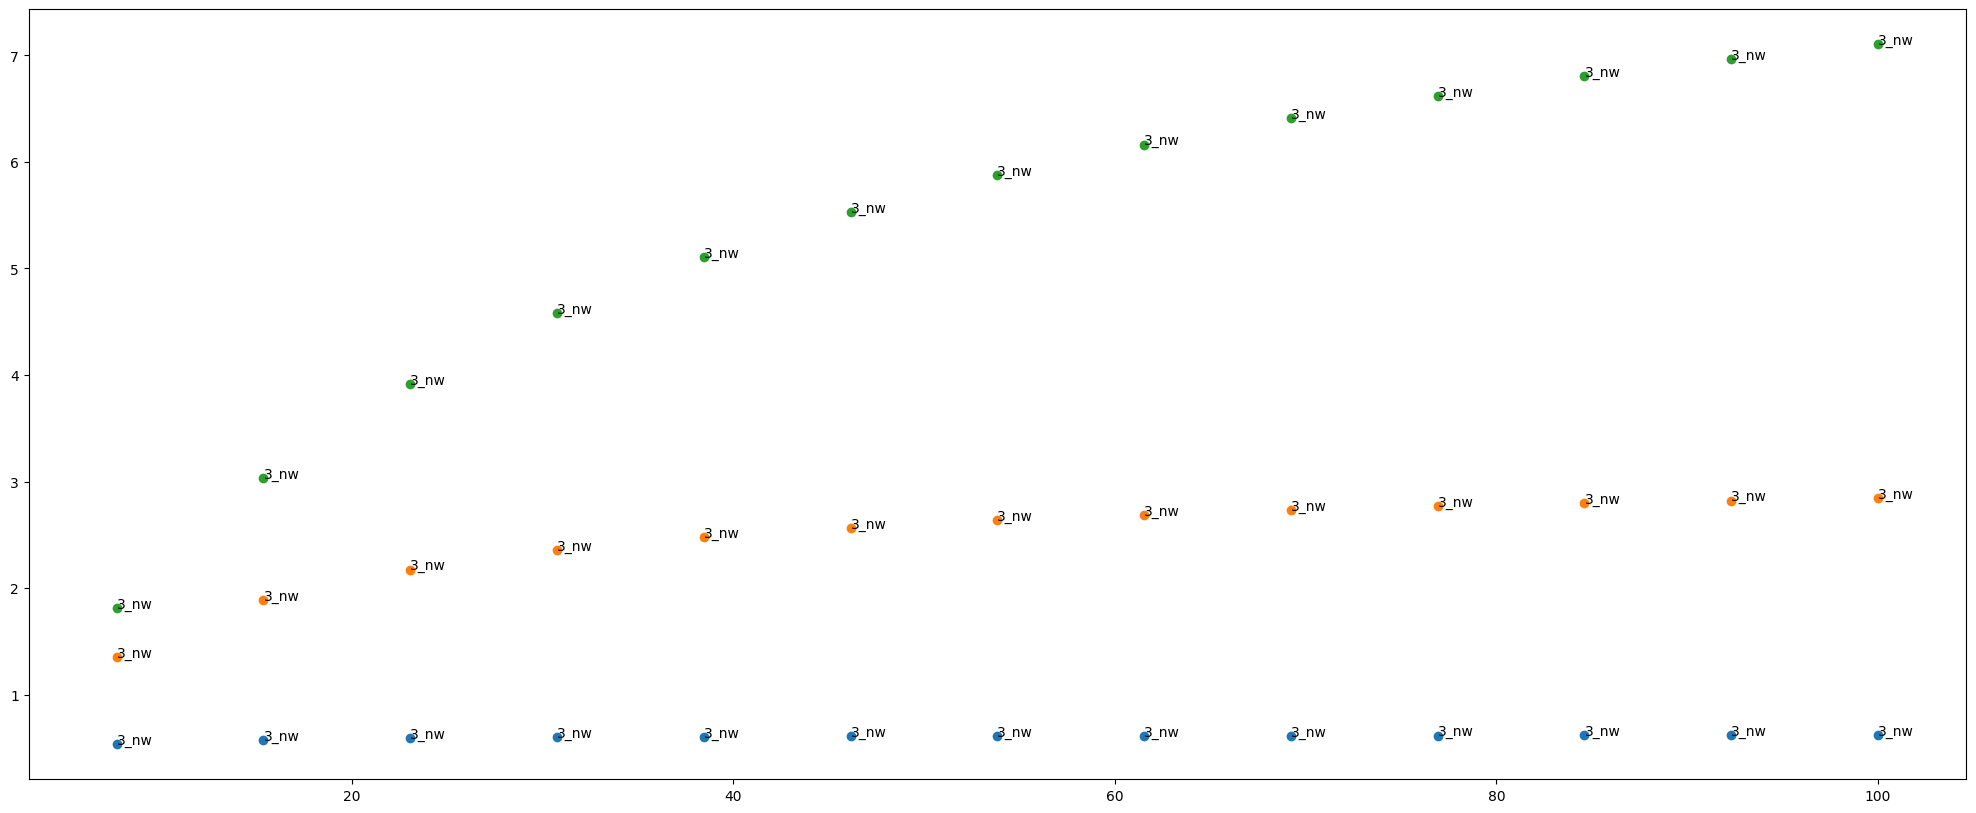

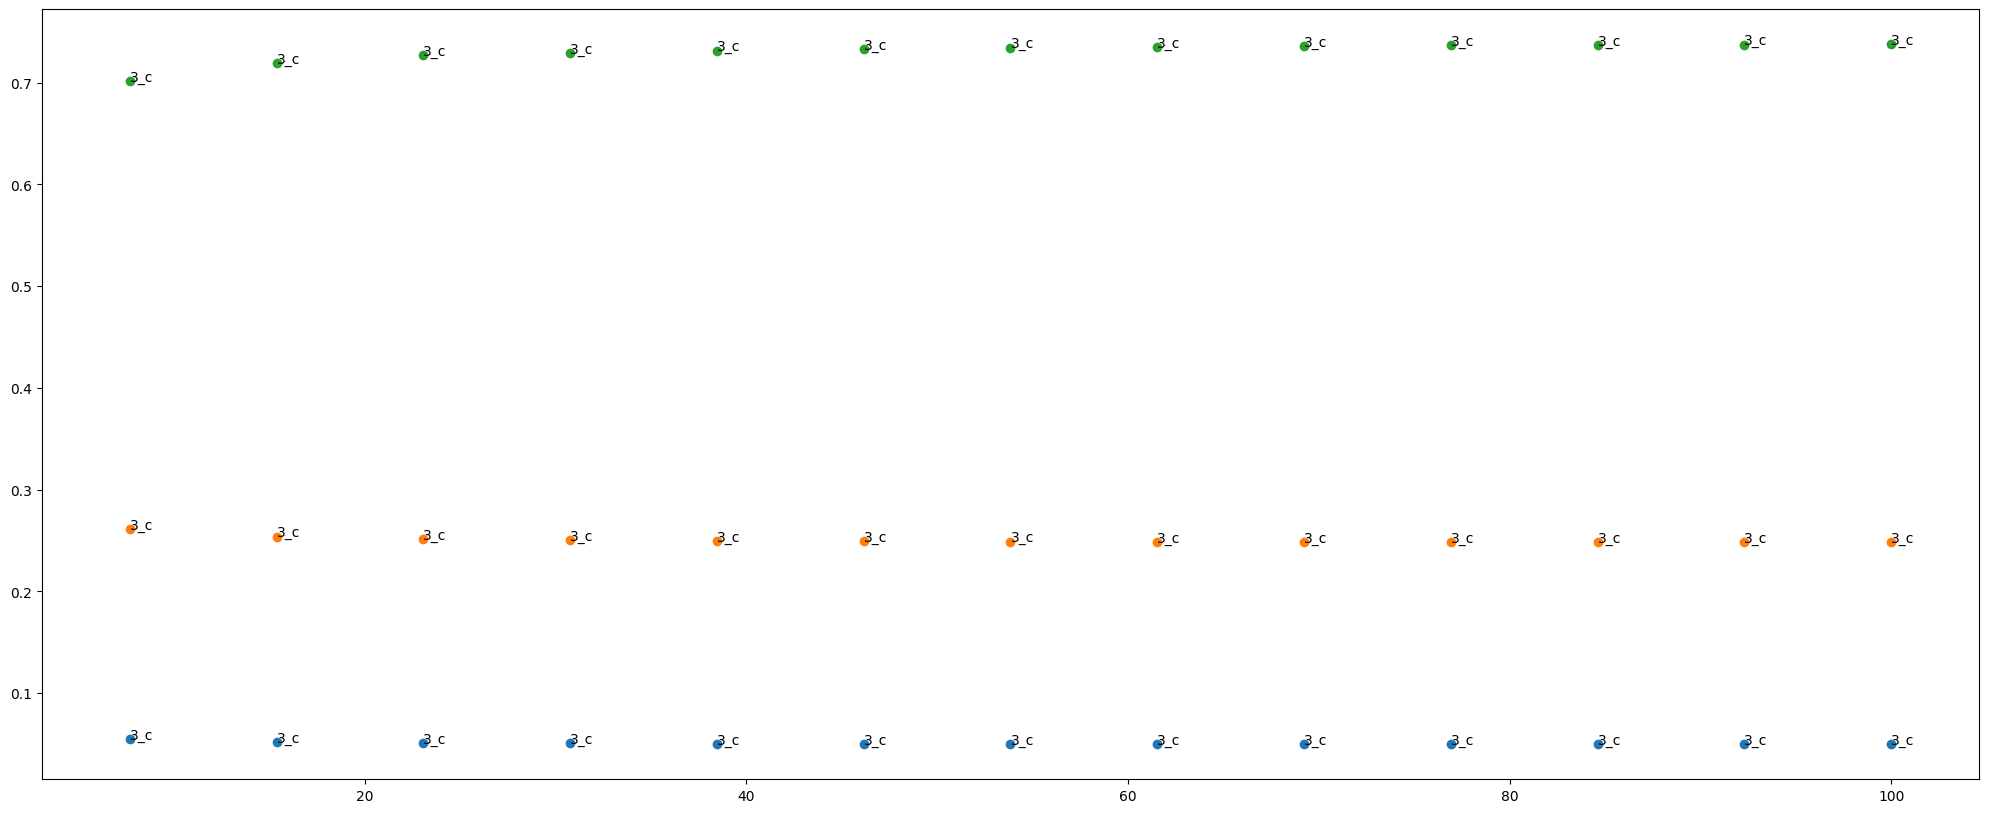

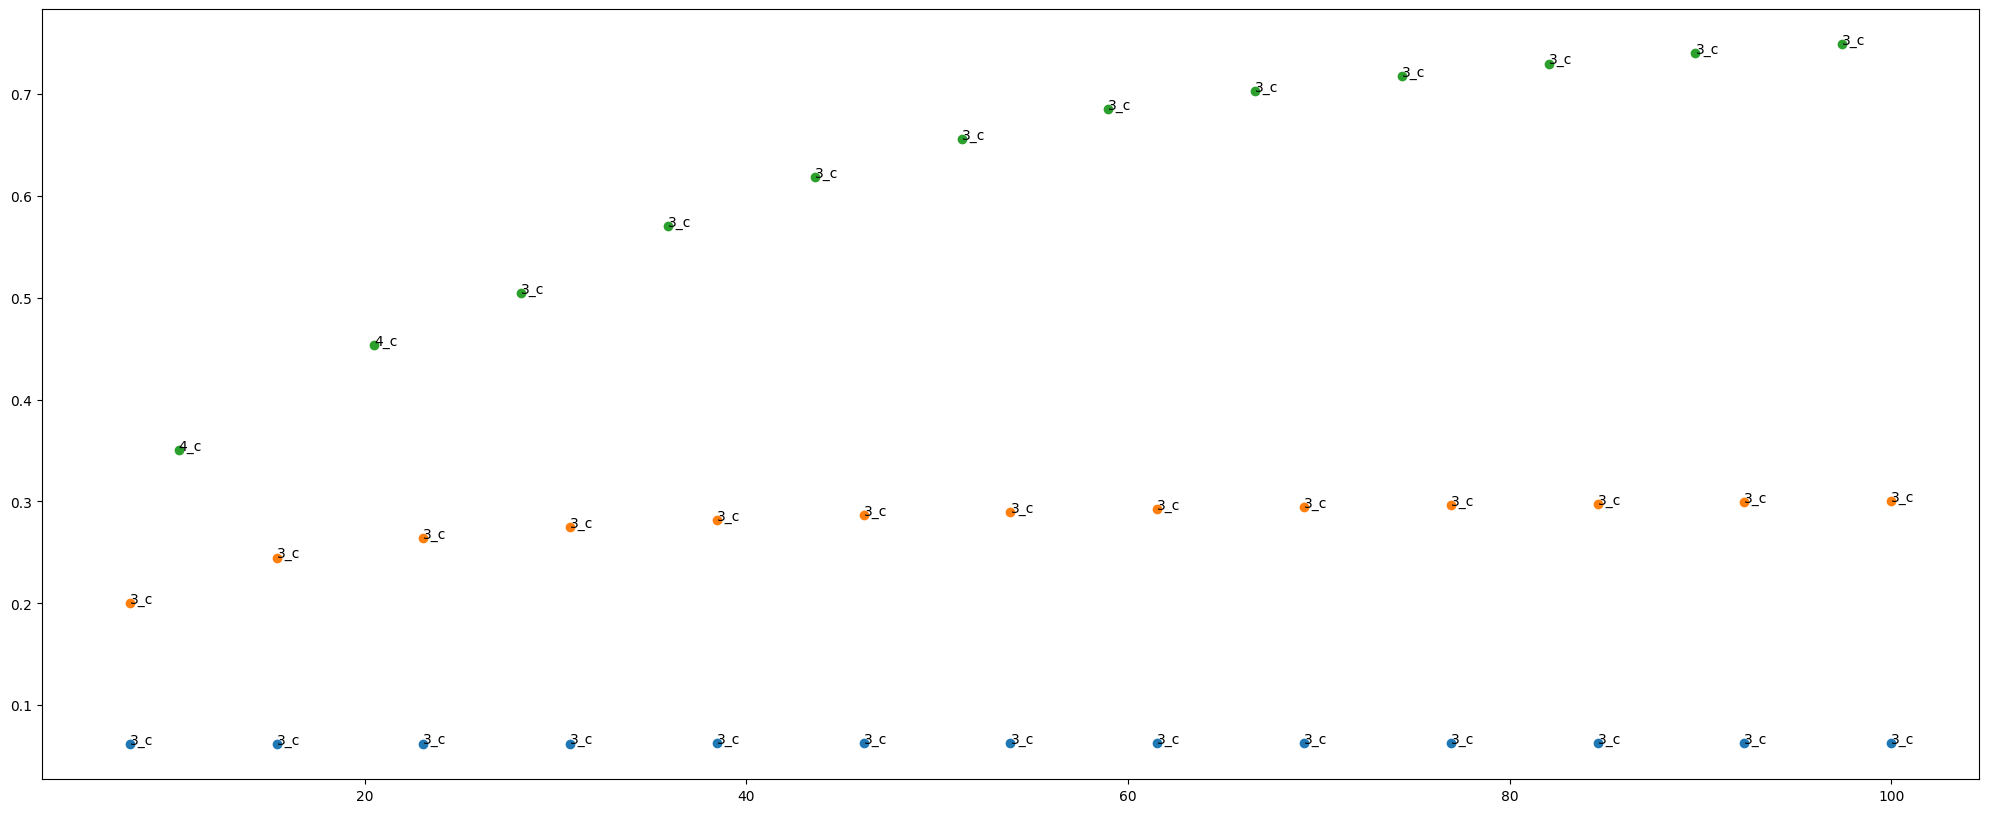

In [88]:
#when is 6 worse than any other combination 
cur_model = "eff"
bw=240
sub="bramble-2-4"
# f=open(f"exploration.detailed.{bw}.10img.debug_w_flop.2_5_and_2_4_avg_err.nw_var_up", "r")
# detailed_map = f.readlines()[0]
# detailed_map = literal_eval(detailed_map.strip())
bg_load=40
fixed_w = 6
model_marker = {"eff":"x", "resnet18":"o", "vit":"^"}
l_w=3
# bws=[2,5,10,20,30,40,50,60,70,80,100,240]
bws=[2,10,30]
for cur_model in ["eff", "resnet18", "vit"]:
    fig, axs = plt.subplots(figsize=(25,10))
    scheduler_trace = {}
    for bw_ind, bw in enumerate(bws):
        load_to_scores={}
        # l_w=4 if cur_model=="vit" else 3
        bg_load = 0
        bg_sum = 0
        # for bg_load in range(1,101):
        min_world = "0"
        counter=-1
        # reset_flag=True
        # reset_overhead=0
        while np.ceil(bg_load)<100:
            min_score = np.inf
            counter+=1
            saved_score=0
            saved_trace={}
            for w in [3,4,6]:
                score_c, std_val, pred_rt, naive_rt, worst_dev_util = best_fit_reader("best_fit_min_2_6.csv", sub, cur_model, w,  bg_load*map_sub[sub]*0.01 ,
                                1, 10, bw=bw, ty='c', col_flag="median", nw_var=True)
                score_nw, std_val, pred_rt, naive_rt, worst_dev_util = best_fit_reader("best_fit_min_2_6.csv", sub, cur_model, w,  bg_load*map_sub[sub]*0.01 ,
                                1, 10, bw=bw, ty='nw', col_flag="median", nw_var=True)
                
                if bg_sum+w <= map_sub[sub]:
                    temp_bg_load = (bg_sum+w)*100/map_sub[sub]
                    temp_scheduler_trace={}
                    if bw in scheduler_trace:
                        temp_scheduler_trace = {k:v for k,v in scheduler_trace[bw].items()}
                    for j in temp_scheduler_trace:
                        ty = j.split("_")[-1]
                        old_w = int(j.split("_")[-2])
                        score, std_val, pred_rt, naive_rt, worst_dev_util = best_fit_reader("best_fit_min_2_6.csv", sub, cur_model, old_w,  temp_bg_load*map_sub[sub]*0.01 - old_w ,
                                        1, 10, bw=bw, ty=ty, col_flag="median", nw_var=True)
                        temp_scheduler_trace[j]=score if score >= temp_scheduler_trace[j] else temp_scheduler_trace[j]
                    vals = list(temp_scheduler_trace.values())
                    add_val = min(score_nw, score_c)
                    add_t = "c" if score_c < score_nw else "nw"
                    if min_score >= max(vals+[add_val]):
                        min_score = max(vals+[add_val])
                        min_world = f"{w}_{add_t}"
                        saved_score = add_val
                        saved_trace = {k:v for k,v in temp_scheduler_trace.items()}


                # if bg_sum+w <= map_sub[sub] and min_score >= min(score_c, score_nw):
                #     min_world = f"{w}_c" if score_c < score_nw else f"{w}_nw"
                #     min_score = min(score_c, score_nw)
            
            bg_sum += int(min_world.split("_")[0])
            bg_load = bg_sum*100/map_sub[sub]
            #reset bg_load once -> acts as a "wait"
            #future jobs get "reset" overhead -> add wait to everyone else's score

            if bg_load > 100:
                break
            # load_to_scores[bg_load] = [min_world, min_score]
            #add to trace
            if bw not in scheduler_trace:
                scheduler_trace[bw] = {}
            #update trace
            #assumes no waiting!
            scheduler_trace[bw]={k:v for k,v in saved_trace.items()}

            # for j in scheduler_trace[bw]:
            #     ty = j.split("_")[-1]
            #     old_w = int(j.split("_")[-2])
            #     score, std_val, pred_rt, naive_rt, worst_dev_util = best_fit_reader("best_fit_min_2_6.csv", sub, cur_model, old_w,  bg_load*map_sub["bramble-2-4"]*0.01 - old_w ,
            #                     1, 10, bw=bw, ty=ty, col_flag="median", nw_var=True)
            #     scheduler_trace[bw][j]=score
            
            scheduler_trace[bw][f"j{counter}_{min_world}"] = saved_score 
            load_to_scores[bg_load] = [min_world, 10*(len(scheduler_trace[bw]))/max(scheduler_trace[bw].values())]
            

            

            
        
        axs.scatter(load_to_scores.keys(), [i[1] for i in load_to_scores.values()], label=f"{bw}")
        for k in load_to_scores.keys():
            axs.text(k, load_to_scores[k][1], load_to_scores[k][0])

        # break
    # break
        # im, cbar = heatmap([[]], , farmers, ax=ax,
        #                 cmap="YlGn", cbarlabel="harvest [t/year]")
        # texts = annotate_heatmap(im, valfmt="{x:.1f} t")

        # fig.tight_layout()
        # plt.show()
        

                

            # score_nw, std_val, pred_rt, naive_rt, worst_dev_util = best_fit_reader("best_fit_min_2_6.csv", sub, cur_model, fixed_w,  bg_load*map_sub["bramble-2-4"]*0.01 - 6 ,
            #                     1, 10, bw=bw, ty='nw', col_flag="median", nw_var=True)
            # score_to_beat = 10/min(score_c, score_nw)
            # real_rt_nw, std_val, pred_rt, naive_rt, worst_dev_util = best_fit_reader("best_fit_min_2_6.csv", sub, cur_model, l_w, bg_load*map_sub["bramble-2-4"]*0.01,
            #                 1, 10, bw=bw, ty="nw", col_flag="median", nw_var=True)
            # real_rt_c, std_val, pred_rt, naive_rt, worst_dev_util = best_fit_reader("best_fit_min_2_6.csv", sub, cur_model, l_w, bg_load*map_sub["bramble-2-4"]*0.01,
            #                 1, 10, bw=bw, ty="c", col_flag="median", nw_var=True)
            # cur_score = 10/min(real_rt_c, real_rt_nw)
            # if cur_score > score_to_beat:
            #     print(cur_model, bw, bg_load, [cur_score, "c" if real_rt_c < real_rt_nw else "nw", score_to_beat, "c" if score_c < score_nw else "nw"])
            # load_to_scores[bg_load] = 

            #     axs.scatter(np.arange(bg_load,101), [bw_ind]*len(np.arange(bg_load,101)), color="green" if cur_score > score_to_beat else "red", marker=model_marker[cur_model], label=f"2x3 split {cur_model}" if cur_score > score_to_beat else f"1x6 split {cur_model}"  )
            #     break
            # else:
            #     axs.scatter(bg_load, bw_ind, color="green" if cur_score > score_to_beat else "red", marker=model_marker[cur_model], label=f"2x3 split {cur_model}" if cur_score > score_to_beat else f"1x6 split {cur_model}"  )

                # break
            # load_to_scores[bg_load] = [cur_score, "c" if real_rt_c < real_rt_nw else "nw", score_to_beat, "c" if score_c < score_nw else "nw"]


        # axs.plot(load_to_scores.keys(), [v[0] for v in load_to_scores.values()], label="2x3 splits", linestyle="--", marker="x")
        # axs.plot(load_to_scores.keys(), [v[2] for v in load_to_scores.values()], label="1x6 splits", linestyle="--", marker="x")
    # axs.legend()
    # axs.set_yticks(np.arange(0,len(bws)))
    # axs.set_yticklabels(bws)

    
        # print(ty, bg_load, cur_score, score_to_beat)

# for w in [3,4,5]:


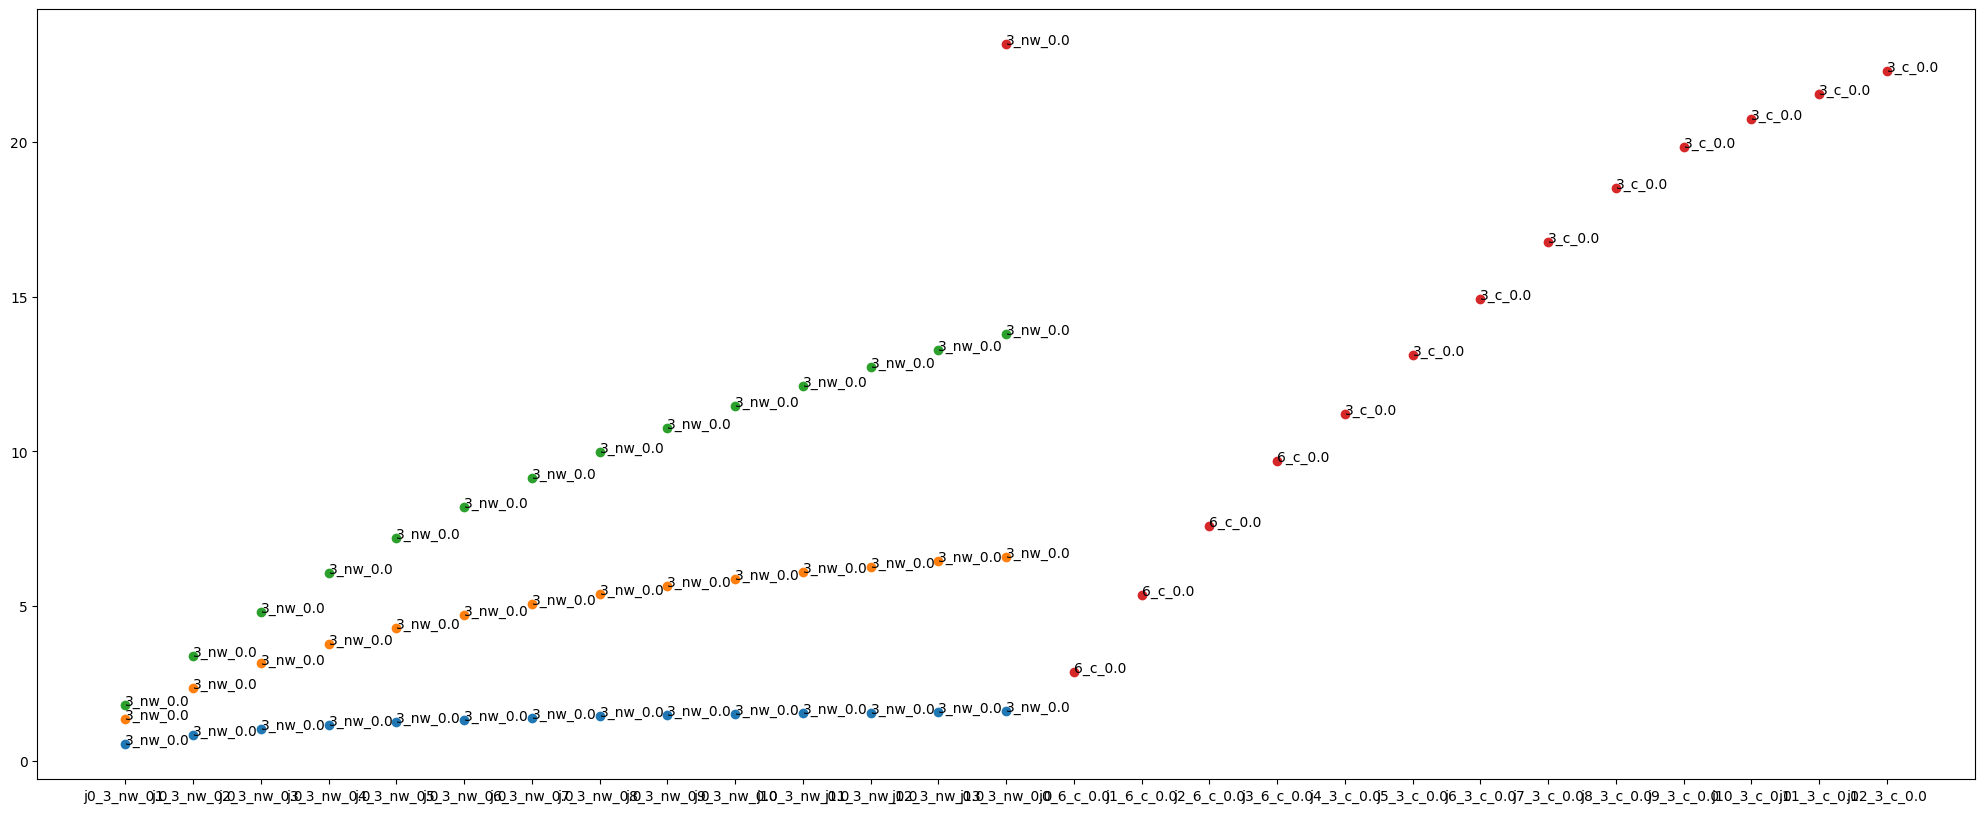

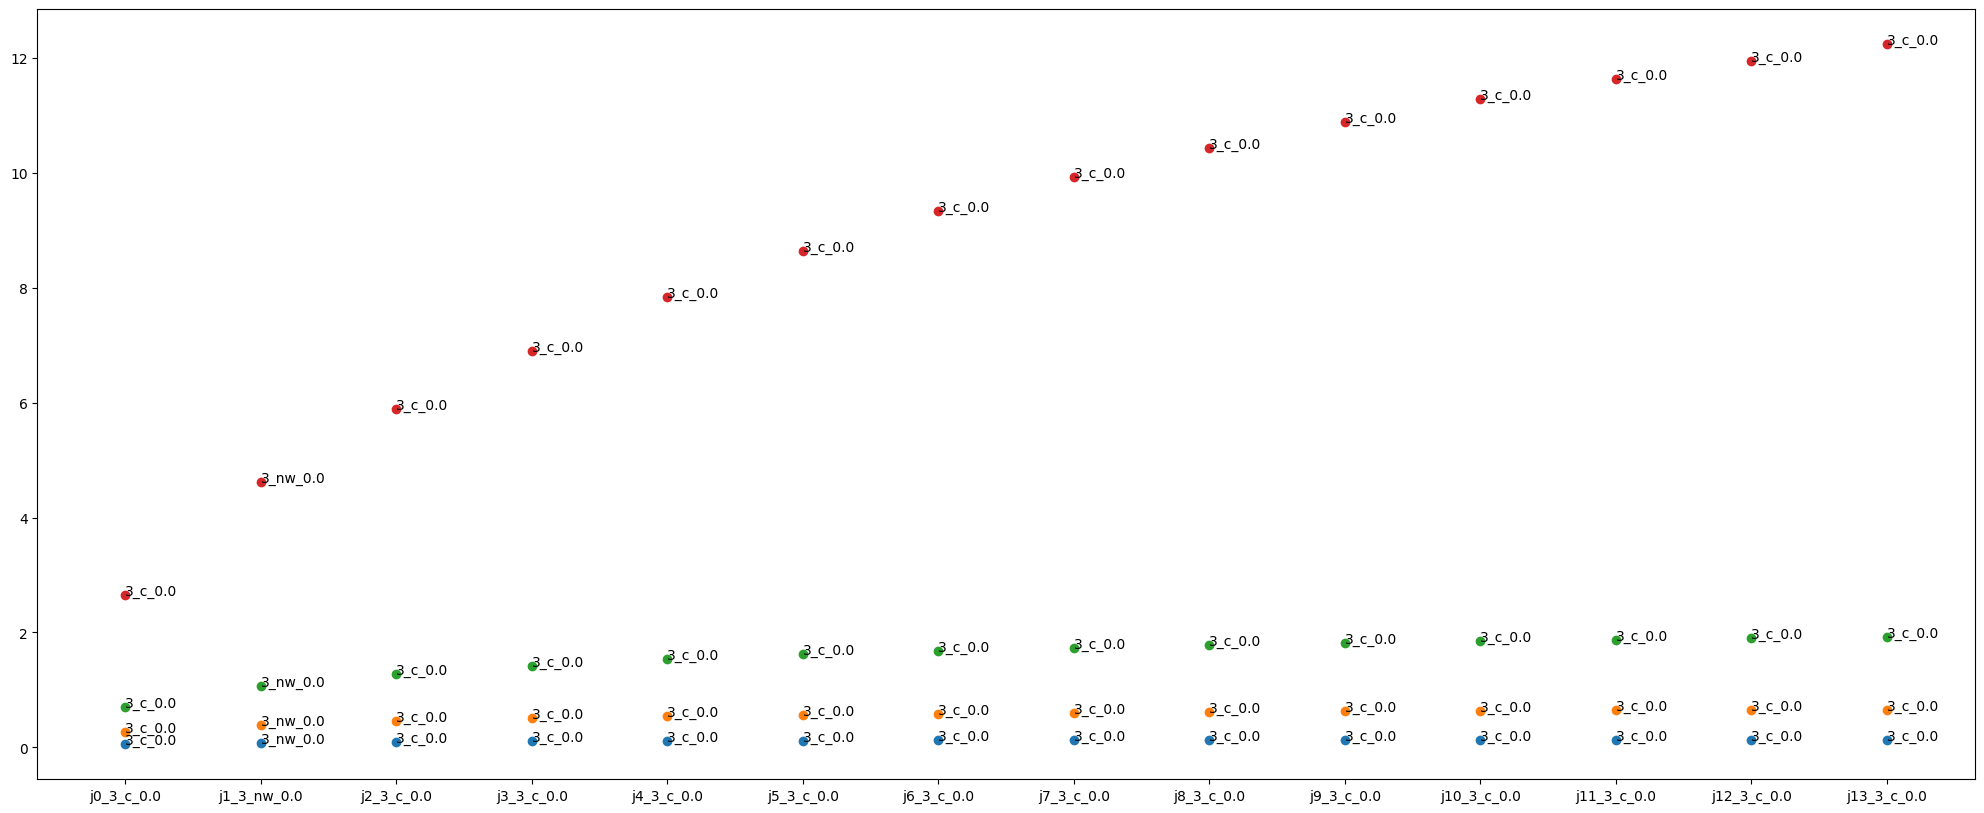

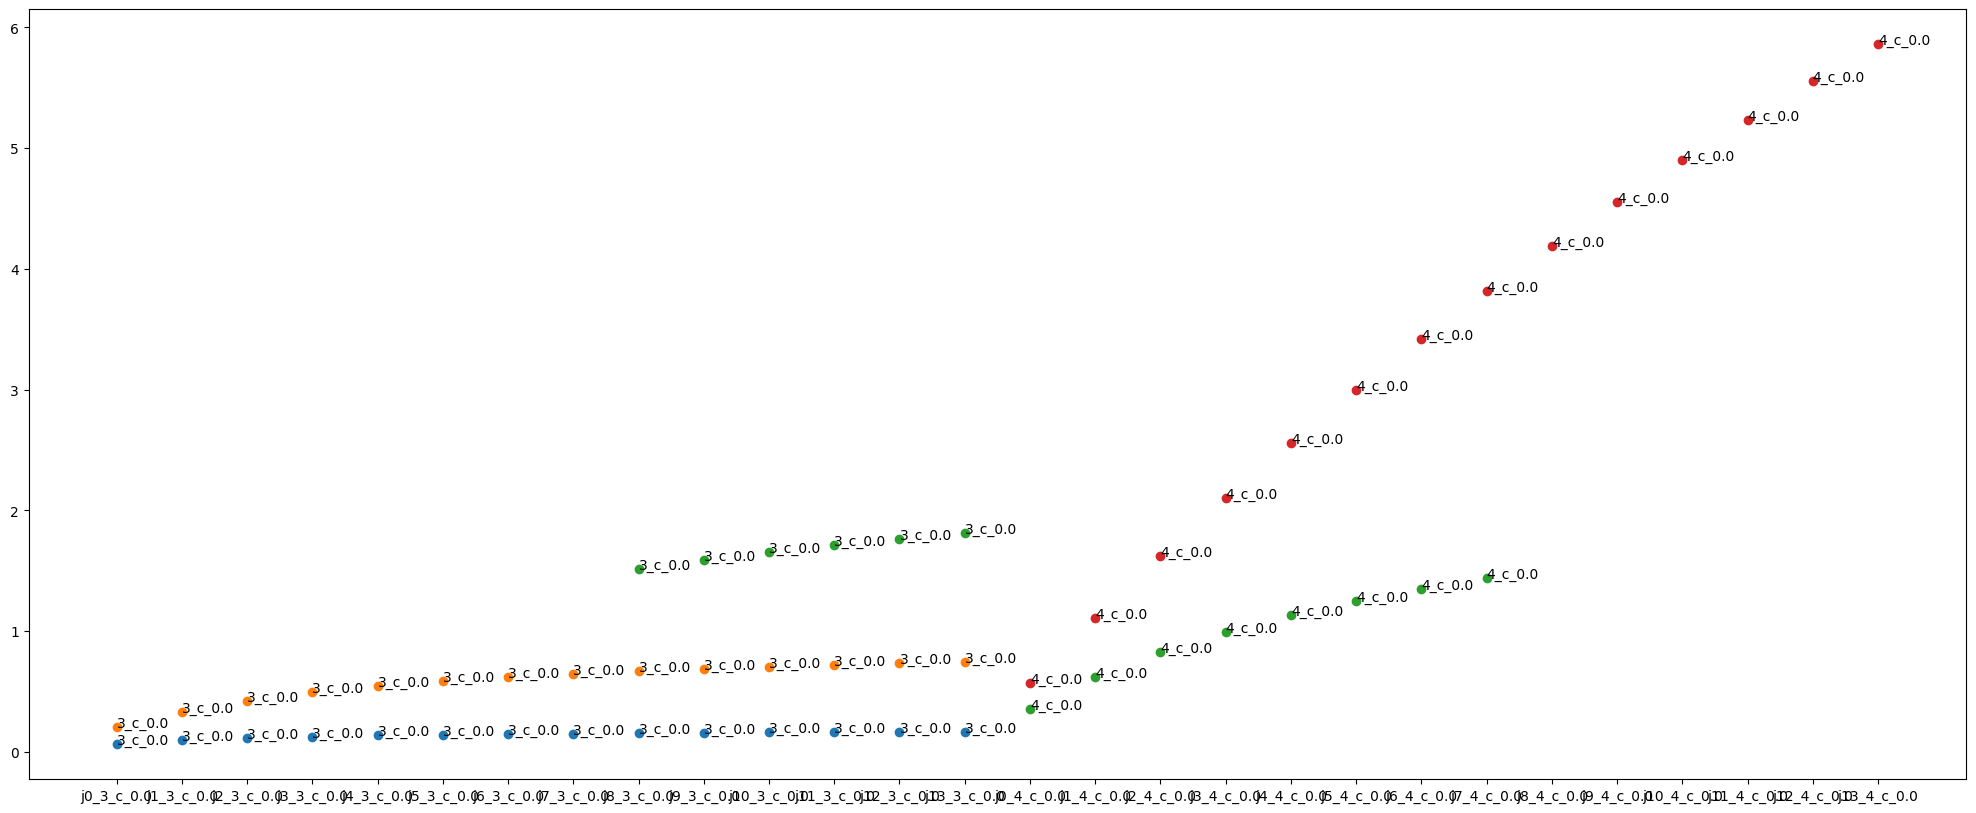

In [93]:
#when is 6 worse than any other combination 
cur_model = "eff"
bw=240
sub="bramble-2-4"
# f=open(f"exploration.detailed.{bw}.10img.debug_w_flop.2_5_and_2_4_avg_err.nw_var_up", "r")
# detailed_map = f.readlines()[0]
# detailed_map = literal_eval(detailed_map.strip())
bg_load=40
fixed_w = 6
model_marker = {"eff":"x", "resnet18":"o", "vit":"^"}
l_w=3
# bws=[2,5,10,20,30,40,50,60,70,80,100,240]
bws=[2,10,30,240]
# bws=[2,10]
for cur_model in ["eff", "resnet18", "vit"]:
# for cur_model in ["resnet18"]:
    fig, axs = plt.subplots(figsize=(25,10))
    scheduler_trace = {}
    for bw_ind, bw in enumerate(bws):
        load_to_scores={}
        # l_w=4 if cur_model=="vit" else 3
        bg_load = 0
        bg_sum = 0
        # for bg_load in range(1,101):
        min_world = "0"
        counter=-1
        concur_map={0.0:0}

        # reset_flag=True
        # reset_overhead=0
        # while np.ceil(bg_load)<100:
        while counter<=12:
            min_score = np.inf
            counter+=1
            saved_score=0
            saved_trace={}
            saved_wait = 0
            #wait time now part of job index in trace
            #j<counter>_<world>_<type>_<wait>
            #all jobs start at same time so no need to worry about arrival time

            #get concurrent jobs
            # print(scheduler_trace, concur_map, counter)
            if bw in scheduler_trace:
                cur_trace = {k:v for k,v in scheduler_trace[bw].items()}
                trace_waits = [float(k.split("_")[-1]) for k in cur_trace]
                concur_map = {}
                for k in trace_waits:
                    if k not in concur_map:
                        concur_map[k]=0
                    concur_map[k]+=1
                #add an extra wait where nothing is running for the option of picking the next wait time
                longest_time = max([cur_trace[k]+float(k.split("_")[-1]) for k in cur_trace])
                concur_map[longest_time]=0
                
                
            for w in [3,4,6]:
                for waits in list(concur_map.keys())[-2:]:
                    #prevents potential older waits leaking into newer ones
                    bg_sum = concur_map[waits]
                    if bg_sum+w <= map_sub[sub]:
                        score_c, std_val, pred_rt, naive_rt, worst_dev_util = best_fit_reader("best_fit_min_2_6.csv", sub, cur_model, w, bg_sum ,
                                1, 10, bw=bw, ty='c', col_flag="median", nw_var=True)
                        score_nw, std_val, pred_rt, naive_rt, worst_dev_util = best_fit_reader("best_fit_min_2_6.csv", sub, cur_model, w, bg_sum ,
                                1, 10, bw=bw, ty='nw', col_flag="median", nw_var=True)
                        temp_bg_load = (bg_sum+w)*100/map_sub[sub]
                        temp_scheduler_trace={}
                        if bw in scheduler_trace:
                            #filter out jobs running at the same time! We only care about those!
                            temp_scheduler_trace = {k:v for k,v in scheduler_trace[bw].items()}
                        for j in temp_scheduler_trace:
                            if f"{waits}" in j:
                                ty = j.split("_")[-2]
                                old_w = int(j.split("_")[-3])
                                score, std_val, pred_rt, naive_rt, worst_dev_util = best_fit_reader("best_fit_min_2_6.csv", sub, cur_model, old_w,  bg_sum+w - old_w ,
                                                1, 10, bw=bw, ty=ty, col_flag="median", nw_var=True)
                                temp_scheduler_trace[j]=score
                        vals = [ temp_scheduler_trace[k]+float(k.split("_")[-1]) for k in temp_scheduler_trace]
                        add_val = min(score_nw+waits, score_c+waits)
                        add_t = "c" if score_c+waits <= score_nw+waits else "nw"
                        if min_score >= max(vals+[add_val]):
                            min_score = max(vals+[add_val])
                            min_world = f"{w}_{add_t}"
                            saved_score = add_val
                            saved_wait = waits
                            saved_trace = {k:v for k,v in temp_scheduler_trace.items()}
                
            if bw not in scheduler_trace:
                scheduler_trace[bw] = {}
            #update trace
            scheduler_trace[bw]={k:v for k,v in saved_trace.items()}
            #add current best option 
            scheduler_trace[bw][f"j{counter}_{min_world}_{saved_wait}"] = saved_score 
            vals = [ scheduler_trace[bw][k]+float(k.split("_")[-1]) for k in scheduler_trace[bw]]
            load_to_scores[f"j{counter}_{min_world}_{saved_wait}"] = [f"{min_world}_{saved_wait}", 10*(len(scheduler_trace[bw]))/max(vals)]
            # if counter==2:
            #     break

            

            
        
        axs.scatter(load_to_scores.keys(), [i[1] for i in load_to_scores.values()], label=f"{bw}")
        for k in load_to_scores.keys():
            axs.text(k, load_to_scores[k][1], load_to_scores[k][0])

    #     break
    # break
        # im, cbar = heatmap([[]], , farmers, ax=ax,
        #                 cmap="YlGn", cbarlabel="harvest [t/year]")
        # texts = annotate_heatmap(im, valfmt="{x:.1f} t")

        # fig.tight_layout()
        # plt.show()
        

                

            # score_nw, std_val, pred_rt, naive_rt, worst_dev_util = best_fit_reader("best_fit_min_2_6.csv", sub, cur_model, fixed_w,  bg_load*map_sub["bramble-2-4"]*0.01 - 6 ,
            #                     1, 10, bw=bw, ty='nw', col_flag="median", nw_var=True)
            # score_to_beat = 10/min(score_c, score_nw)
            # real_rt_nw, std_val, pred_rt, naive_rt, worst_dev_util = best_fit_reader("best_fit_min_2_6.csv", sub, cur_model, l_w, bg_load*map_sub["bramble-2-4"]*0.01,
            #                 1, 10, bw=bw, ty="nw", col_flag="median", nw_var=True)
            # real_rt_c, std_val, pred_rt, naive_rt, worst_dev_util = best_fit_reader("best_fit_min_2_6.csv", sub, cur_model, l_w, bg_load*map_sub["bramble-2-4"]*0.01,
            #                 1, 10, bw=bw, ty="c", col_flag="median", nw_var=True)
            # cur_score = 10/min(real_rt_c, real_rt_nw)
            # if cur_score > score_to_beat:
            #     print(cur_model, bw, bg_load, [cur_score, "c" if real_rt_c < real_rt_nw else "nw", score_to_beat, "c" if score_c < score_nw else "nw"])
            # load_to_scores[bg_load] = 

            #     axs.scatter(np.arange(bg_load,101), [bw_ind]*len(np.arange(bg_load,101)), color="green" if cur_score > score_to_beat else "red", marker=model_marker[cur_model], label=f"2x3 split {cur_model}" if cur_score > score_to_beat else f"1x6 split {cur_model}"  )
            #     break
            # else:
            #     axs.scatter(bg_load, bw_ind, color="green" if cur_score > score_to_beat else "red", marker=model_marker[cur_model], label=f"2x3 split {cur_model}" if cur_score > score_to_beat else f"1x6 split {cur_model}"  )

                # break
            # load_to_scores[bg_load] = [cur_score, "c" if real_rt_c < real_rt_nw else "nw", score_to_beat, "c" if score_c < score_nw else "nw"]


        # axs.plot(load_to_scores.keys(), [v[0] for v in load_to_scores.values()], label="2x3 splits", linestyle="--", marker="x")
        # axs.plot(load_to_scores.keys(), [v[2] for v in load_to_scores.values()], label="1x6 splits", linestyle="--", marker="x")
    # axs.legend()
    # axs.set_yticks(np.arange(0,len(bws)))
    # axs.set_yticklabels(bws)

    
        # print(ty, bg_load, cur_score, score_to_beat)

# for w in [3,4,5]:


In [ ]:
#when is 6 worse than any other combination 
cur_model = "eff"
bw=240
sub="bramble-2-4"
# f=open(f"exploration.detailed.{bw}.10img.debug_w_flop.2_5_and_2_4_avg_err.nw_var_up", "r")
# detailed_map = f.readlines()[0]
# detailed_map = literal_eval(detailed_map.strip())
bg_load=40
fixed_w = 6
model_marker = {"eff":"x", "resnet18":"o", "vit":"^"}
l_w=3
# bws=[2,5,10,20,30,40,50,60,70,80,100,240]
bws=[2,10,30,240]
# bws=[2,10]
for cur_model in ["eff", "resnet18", "vit"]:
# for cur_model in ["resnet18"]:
    fig, axs = plt.subplots(figsize=(25,10))
    scheduler_trace = {}
    for bw_ind, bw in enumerate(bws):
        load_to_scores={}
        # l_w=4 if cur_model=="vit" else 3
        bg_load = 0
        bg_sum = 0
        # for bg_load in range(1,101):
        min_world = "0"
        counter=-1
        concur_map={0.0:0}

        # reset_flag=True
        # reset_overhead=0
        # while np.ceil(bg_load)<100:
        while counter<=12:
            min_score = np.inf
            counter+=1
            saved_score=0
            saved_trace={}
            saved_wait = 0
            #wait time now part of job index in trace
            #j<counter>_<world>_<type>_<wait>
            #all jobs start at same time so no need to worry about arrival time

            #get concurrent jobs
            # print(scheduler_trace, concur_map, counter)
            if bw in scheduler_trace:
                cur_trace = {k:v for k,v in scheduler_trace[bw].items()}
                trace_waits = [float(k.split("_")[-1]) for k in cur_trace]
                concur_map = {}
                for k in trace_waits:
                    if k not in concur_map:
                        concur_map[k]=0
                    concur_map[k]+=1
                #add an extra wait where nothing is running for the option of picking the next wait time
                longest_time = max([cur_trace[k]+float(k.split("_")[-1]) for k in cur_trace])
                concur_map[longest_time]=0
                
                
            for w in [3,4,6]:
                for waits in list(concur_map.keys())[-2:]:
                    #prevents potential older waits leaking into newer ones
                    bg_sum = concur_map[waits]
                    if bg_sum+w <= map_sub[sub]:
                        score_c, std_val, pred_rt, naive_rt, worst_dev_util = best_fit_reader("best_fit_min_2_6.csv", sub, cur_model, w, bg_sum ,
                                1, 10, bw=bw, ty='c', col_flag="median", nw_var=True)
                        score_nw, std_val, pred_rt, naive_rt, worst_dev_util = best_fit_reader("best_fit_min_2_6.csv", sub, cur_model, w, bg_sum ,
                                1, 10, bw=bw, ty='nw', col_flag="median", nw_var=True)
                        temp_bg_load = (bg_sum+w)*100/map_sub[sub]
                        temp_scheduler_trace={}
                        if bw in scheduler_trace:
                            #filter out jobs running at the same time! We only care about those!
                            temp_scheduler_trace = {k:v for k,v in scheduler_trace[bw].items()}
                        for j in temp_scheduler_trace:
                            if f"{waits}" in j:
                                ty = j.split("_")[-2]
                                old_w = int(j.split("_")[-3])
                                score, std_val, pred_rt, naive_rt, worst_dev_util = best_fit_reader("best_fit_min_2_6.csv", sub, cur_model, old_w,  bg_sum+w - old_w ,
                                                1, 10, bw=bw, ty=ty, col_flag="median", nw_var=True)
                                temp_scheduler_trace[j]=score
                        vals = [ temp_scheduler_trace[k]+float(k.split("_")[-1]) for k in temp_scheduler_trace]
                        add_val = min(score_nw+waits, score_c+waits)
                        add_t = "c" if score_c+waits < score_nw+waits else "nw"
                        if min_score >= max(vals+[add_val]):
                            min_score = max(vals+[add_val])
                            min_world = f"{w}_{add_t}"
                            saved_score = add_val
                            saved_wait = waits
                            saved_trace = {k:v for k,v in temp_scheduler_trace.items()}
                
            if bw not in scheduler_trace:
                scheduler_trace[bw] = {}
            #update trace
            scheduler_trace[bw]={k:v for k,v in saved_trace.items()}
            #add current best option 
            scheduler_trace[bw][f"j{counter}_{min_world}_{saved_wait}"] = saved_score 
            vals = [ scheduler_trace[bw][k]+float(k.split("_")[-1]) for k in scheduler_trace[bw]]
            load_to_scores[f"j{counter}_{min_world}_{saved_wait}"] = [f"{min_world}_{saved_wait}", 10*(len(scheduler_trace[bw]))/max(vals)]
            # if counter==2:
            #     break

            

            
        
        axs.scatter(load_to_scores.keys(), [i[1] for i in load_to_scores.values()], label=f"{bw}")
        for k in load_to_scores.keys():
            axs.text(k, load_to_scores[k][1], load_to_scores[k][0])

    #     break
    # break
        # im, cbar = heatmap([[]], , farmers, ax=ax,
        #                 cmap="YlGn", cbarlabel="harvest [t/year]")
        # texts = annotate_heatmap(im, valfmt="{x:.1f} t")

        # fig.tight_layout()
        # plt.show()
        

                

            # score_nw, std_val, pred_rt, naive_rt, worst_dev_util = best_fit_reader("best_fit_min_2_6.csv", sub, cur_model, fixed_w,  bg_load*map_sub["bramble-2-4"]*0.01 - 6 ,
            #                     1, 10, bw=bw, ty='nw', col_flag="median", nw_var=True)
            # score_to_beat = 10/min(score_c, score_nw)
            # real_rt_nw, std_val, pred_rt, naive_rt, worst_dev_util = best_fit_reader("best_fit_min_2_6.csv", sub, cur_model, l_w, bg_load*map_sub["bramble-2-4"]*0.01,
            #                 1, 10, bw=bw, ty="nw", col_flag="median", nw_var=True)
            # real_rt_c, std_val, pred_rt, naive_rt, worst_dev_util = best_fit_reader("best_fit_min_2_6.csv", sub, cur_model, l_w, bg_load*map_sub["bramble-2-4"]*0.01,
            #                 1, 10, bw=bw, ty="c", col_flag="median", nw_var=True)
            # cur_score = 10/min(real_rt_c, real_rt_nw)
            # if cur_score > score_to_beat:
            #     print(cur_model, bw, bg_load, [cur_score, "c" if real_rt_c < real_rt_nw else "nw", score_to_beat, "c" if score_c < score_nw else "nw"])
            # load_to_scores[bg_load] = 

            #     axs.scatter(np.arange(bg_load,101), [bw_ind]*len(np.arange(bg_load,101)), color="green" if cur_score > score_to_beat else "red", marker=model_marker[cur_model], label=f"2x3 split {cur_model}" if cur_score > score_to_beat else f"1x6 split {cur_model}"  )
            #     break
            # else:
            #     axs.scatter(bg_load, bw_ind, color="green" if cur_score > score_to_beat else "red", marker=model_marker[cur_model], label=f"2x3 split {cur_model}" if cur_score > score_to_beat else f"1x6 split {cur_model}"  )

                # break
            # load_to_scores[bg_load] = [cur_score, "c" if real_rt_c < real_rt_nw else "nw", score_to_beat, "c" if score_c < score_nw else "nw"]


        # axs.plot(load_to_scores.keys(), [v[0] for v in load_to_scores.values()], label="2x3 splits", linestyle="--", marker="x")
        # axs.plot(load_to_scores.keys(), [v[2] for v in load_to_scores.values()], label="1x6 splits", linestyle="--", marker="x")
    # axs.legend()
    # axs.set_yticks(np.arange(0,len(bws)))
    # axs.set_yticklabels(bws)

    
        # print(ty, bg_load, cur_score, score_to_beat)

# for w in [3,4,5]:


full schedule gives rmse: 11.80127956525261, mae: 11.80127956525261
{'greedy_eff_240_1.0_w/o_leeway': [[3.281, 1.296, 3.417], 17.12, 5.84]}


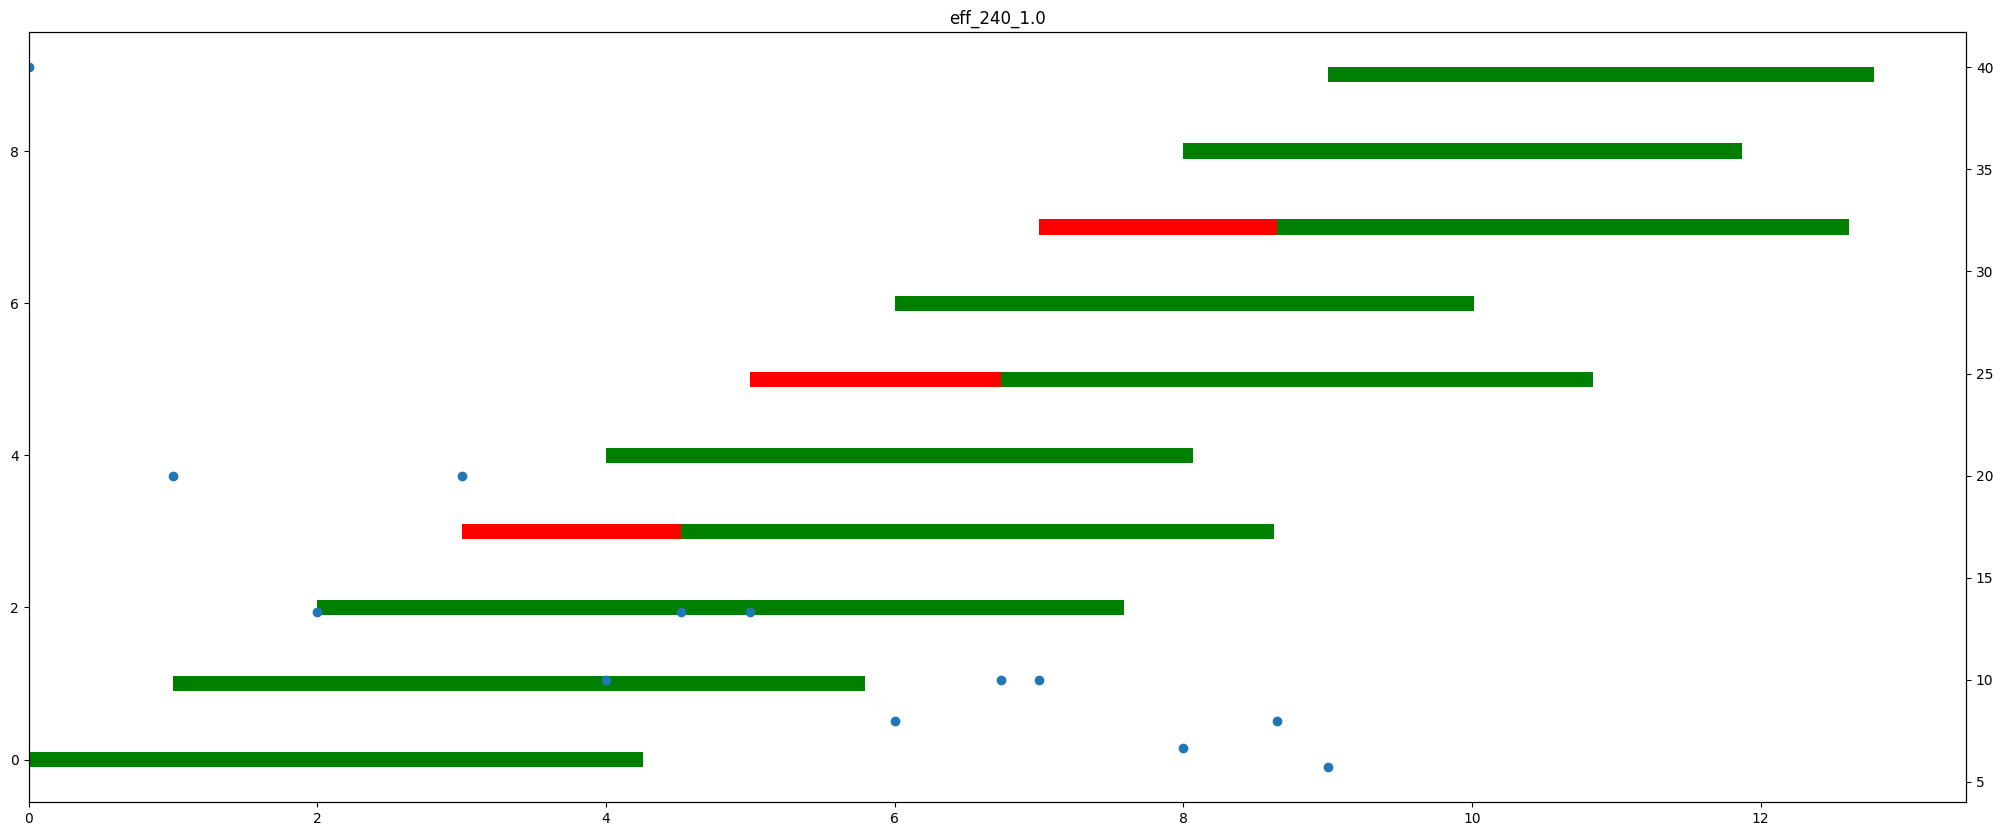

In [58]:
data_collector={}
sub="bramble-2-4"
inp=10
pred_schedule = []
real_schedule = []
# for cur_model in ["resnet18", "vit", "eff"]:
fix=6
for cur_model in ["eff"]:
    # for lee in [0,1]:
    for lee in [0]:
        # for iat in [0.5, 1.0, 10.0]:
        # for iat in [ 10.0]:
        # for iat in [1.0, 10.0]:
        for iat in [1.0]:
            # for bw in [240, 30, 10, 2]:
            for bw in [240]:
            # for bw in [2]:
                pred_y=[]
                real_y=[]

                # cur_model="resnet18"
                # filename = f"/Users/animeshnd/model_splitting/scheduler/sim.op.bramble-2-4.{cur_model}.{bw}.{iat}.uniform.duty_cycle.{'no_leeway' if lee==0 else 'leeway'}"
                filename = f"/Users/animeshnd/model_splitting/scheduler/sim.op.bramble-2-4.{cur_model}.{bw}.{iat}.uniform.duty_cycle.{'no_leeway' if lee==0 else 'leeway'}.fixed.{fix}"
                
                ts, overhead, bs, bn, world, added_time, ty, _, devs_used, bw_used = simulation_reader(filename, skip_ts=False, agg_flag="exp")
                fig, bar_axs = plt.subplots(figsize=(25,10))
                bar_axs.set_title(f"{cur_model}_{bw}_{iat}")
                bar_axs1 = bar_axs.twinx()
                #convert job association to time association
                j_x=[]
                j_y=[]
                count=0
                visited=[]
                for j in overhead:
                    if j=="j10":
                        break
                    real_ts, std_val, pred_rt, naive_rt, worst_dev_util = best_fit_reader("best_fit_max_2_6.csv", sub, cur_model, world[j], overhead[j]-world[j],
                    bs[j], bn[j], bw=bw_used[j] if bw!=2 else 2, ty=ty[j], col_flag="median", agg_flag="mean", nw_var=True if bw==2 else False)

                    exceed_times = sum([1*fix for i in visited if (sum(added_time[j])-i)>=0])
                    # print(exceed_times, count, j)
                    if exceed_times >0:
                        visited = [i for i in visited if (sum(added_time[j])-i)<0]
                        count-=exceed_times
                        # print(exceed_times, count, j)
                        if added_time[j][1]>0:
                            j_x.append(added_time[j][0])
                            j_y.append(bw/count)
                    # if added_time[j][1]>0:
                    #     j_x.append(added_time[j][0])
                    #     j_y.append(bw/(count-fix))

                    count+=fix
                    # print(exceed_times, count, j)
    
                    # visited.append(real_ts+sum(added_time[j]))
                    visited.append(ts[j])
                    j_x.append(sum(added_time[j]))
                    # print(j_x)
                    j_y.append(bw/count)
                    


                    # if added_time[j][1] == 0: 
                    #     count+=3
                    #     j_x.append(added_time[j][0]+added_time[j][1])
                    #     j_y.append(bw/overhead[j])
                    # else:

                
                # bar_axs1.step(j_x, j_y, where="mid")
                bar_axs1.scatter(j_x, j_y)

                arr_times = []
                dev_to_s_map={}
                real_ts={}
                run_ts = {k:ts[k]-sum(added_time[k]) for k in ts}
                pred_y = [ts[k]-sum(added_time[k]) for k in ts]
                for j in ts:
                    if j=="j10":
                        break
                    ind = int(j.split("j")[-1])

                    if j not in real_ts:
                        real_ts[j]=0
                    
                    real_ts[j], std_val, pred_rt, naive_rt, worst_dev_util = best_fit_reader("best_fit_max_2_6.csv", sub, cur_model, world[j], overhead[j]-world[j],
                    bs[j], bn[j], bw=bw_used[j] if bw!=2 else 2, ty=ty[j], col_flag="median", agg_flag="mean", nw_var=True if bw==2 else False)
                    dev_str = devs_used[j]
                    for dev in dev_str.split("."):
                        if dev not in dev_to_s_map:
                            dev_to_s_map[dev]=[]
                        else:
                            dev_to_s_map[dev].append(worst_dev_util)
                        
                    
                    # print(bs[j], bn[j])
                    arr_t = added_time[j][0]
                    wait_t = added_time[j][1]
                    # specific_waits.append(wait_t)
                    # only_wait_ts[j] =  arr_t+wait_t
                    # real_ts[j] = arr_t+wait_t+real_ts[j] 
                    
                    bar_axs.barh(ind, wait_t, left=arr_t, color="red", height=0.2 )
                    # bar_axs.barh(ind, ts[j]-sum(added_time[j]), color="green", left=(sum(added_time[j])), height=0.2)
                    bar_axs.barh(ind, real_ts[j], color="green", left=(sum(added_time[j])), height=0.2)
                    
                    real_y.append(real_ts[j])
                    real_ts[j]+=added_time[j][1]#sum(added_time[j]) #compensate for wait time and accurately calculate the time per device!
                    # bar_axs.barh(ind, pred_rt, color="green", left=(sum(added_time[j])), height=0.2)
                    # bar_axs.text(ts[j], ind, f'{world[j]}_{ty[j]}')
                    # bar_axs.text(real_ts[j]+added_time[j][0], ind, f'{world[j]}_{ty[j]}')
                # print(f"{iat} arrival times with bw {bw} and model {cur_model}",
                # f"gives rmse: { np.sqrt( np.mean([(pred_y[i]-real_y[i])**2 for i in range(len(pred_y))]) ) }, mae: {np.mean([abs(pred_y[i]-real_y[i]) for i in range(len(pred_y))])}")
                s_per_mac = float(round( sum([sum(dev_to_s_map[dev]) for dev in dev_to_s_map if len(dev_to_s_map[dev])!=0])/map_sub['bramble-2-4'],3 ))
                min_s_per_mac = float(round( min([sum(dev_to_s_map[dev]) for dev in dev_to_s_map if len(dev_to_s_map[dev])!=0]+[np.inf]),3 ))
                max_s_per_mac = float(round( max([sum(dev_to_s_map[dev]) for dev in dev_to_s_map if len(dev_to_s_map[dev])!=0]+[0]),3 ))

                run_real_ts = {k:real_ts[k]-added_time[k][1] for k in real_ts}
                pred_schedule.append(max(run_ts.values()))
                real_schedule.append(max(run_real_ts.values()))

                # s_per_mac = float(round( np.mean([sum(dev_to_s_map[dev]) for dev in dev_to_s_map if len(dev_to_s_map[dev])!=0]),3 ))
                # print(f"greedy {cur_model} {iat} {bw} s/machine used {'w/' if lee==1 else 'w/o'} leeway: {s_per_mac}")
                th = float(round(10*len(real_ts)/max(real_ts.values()),3))
                # print(f"overall throughput greedy {cur_model} {iat} {bw} {'w/' if lee==1 else 'w/o'} leeway: {th} ")
                data_collector[f"greedy_{cur_model}_{bw}_{iat}_{'w/' if lee==1 else 'w/o'}_leeway"]=[ [min_s_per_mac, s_per_mac, max_s_per_mac], th, float(round(max(real_ts.values()),2))]
                for j in ts:
                    ind = int(j.split("j")[-1])
                    w=added_time[j][1]
                    arr = added_time[j][0]
                    arr_times.append(arr)
                    # bar_axs.barh(ind, w, left=arr, color="red" )
                    # bar_axs.barh(ind, ts[j]-(sum(added_time[j])), color="green", left=(sum(added_time[j])), height=0.2)
                    # bar_axs.barh(ind, arr, edgecolor="black", color='none')

                # bar_axs1=bar_axs.twinx()
                # bar_axs1.scatter(arr_times, [round(100*overhead[i]/map_sub["bramble-2-4"],2) for i in overhead], marker="x", color="green")

               
    print(f"full schedule gives rmse: { np.sqrt( np.mean([(real_schedule[i]-pred_schedule[i])**2 for i in range(len(pred_schedule))]) ) }, mae: {np.mean([abs(pred_schedule[i]-real_schedule[i]) for i in range(len(pred_schedule))])}")
    print(data_collector)